In [1]:
# ! pip install vnstock3 joblib matplotlib scikit-learn icecream

In [2]:
# from update_data import *
from static import *
from stock_data import *
from scipy.stats.mstats import winsorize
from bao import *

# from scipy.stats.mstats import winsorize
stock = StockData("./data/stock/", "./stock_dictionary.json")

In [3]:
stock_data = stock.get_data()

In [4]:
indies_data = stock.get_indices_data()

In [5]:
whole_data = pd.concat([stock_data] + indies_data, axis=0)

In [6]:
# Compute market level return
market = (
    whole_data.groupby(["exchange", "time"])[
        [
            "return_weighted",
            "log_return_weighted",
        ]
    ]
    .sum()
    .reset_index()
)

## winsorize the outliner

In [7]:
market_winsored = pd.DataFrame()
for i in market["exchange"].unique():
    temp = market.loc[market["exchange"] == i]
    temp["return_weighted"] = winsorize(
        temp["return_weighted"], limits=[0.05, 0.05]
    )
    temp["log_return_weighted"] = winsorize(
        temp["log_return_weighted"], limits=[0.05, 0.05]
    )
    market_winsored = pd.concat([market_winsored, temp], axis=0)
    # Detect outliers using Z-score

# Auto Regression

In [8]:
from AR import *

data = market_winsored[market_winsored["exchange"] == "vni"]
data.index = pd.date_range(
    start=data["time"].min(),
    periods=len(data),
    freq="B",
)

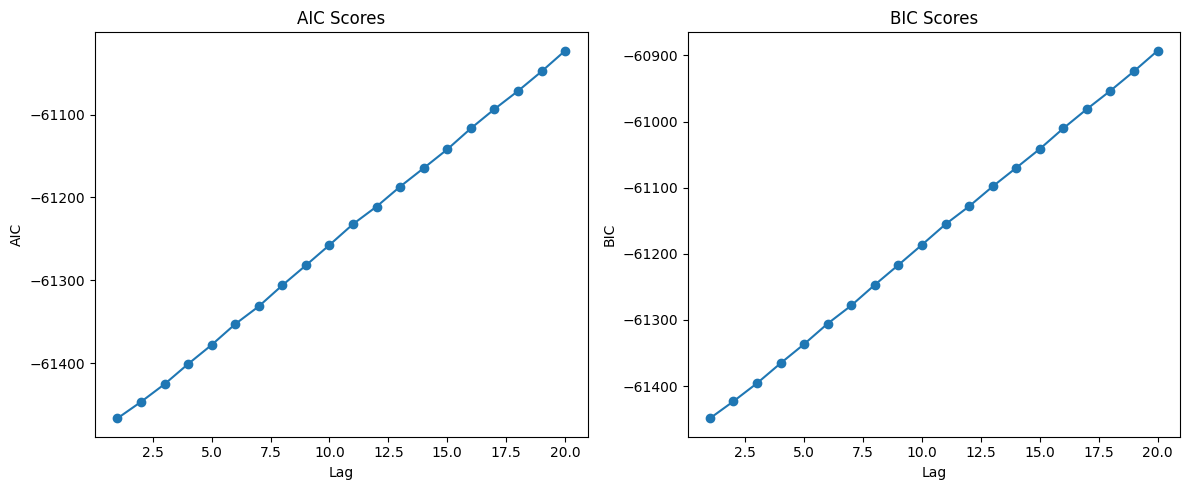

{'best_aic_lag': 1,
 'best_bic_lag': 1,
 'aic_scores': {1: np.float64(-61466.48788505363),
  2: np.float64(-61446.63145238073),
  3: np.float64(-61425.2434164858),
  4: np.float64(-61400.91617187318),
  5: np.float64(-61377.864362823),
  6: np.float64(-61352.76169510366),
  7: np.float64(-61331.34402406116),
  8: np.float64(-61305.957767306674),
  9: np.float64(-61281.869669041516),
  10: np.float64(-61257.30219662902),
  11: np.float64(-61232.11053167079),
  12: np.float64(-61210.94079765029),
  13: np.float64(-61186.84449930041),
  14: np.float64(-61164.560306096886),
  15: np.float64(-61141.92976193599),
  16: np.float64(-61116.65946509082),
  17: np.float64(-61093.4106716583),
  18: np.float64(-61071.54879490057),
  19: np.float64(-61047.993128309325),
  20: np.float64(-61022.93489940691)},
 'bic_scores': {1: np.float64(-61448.7363690871),
  2: np.float64(-61422.96422241698),
  3: np.float64(-61395.66120218519),
  4: np.float64(-61365.41970329536),
  5: np.float64(-61336.4543704273

In [9]:
# Run different selection methods
info_criteria_selection(data["return_weighted"])

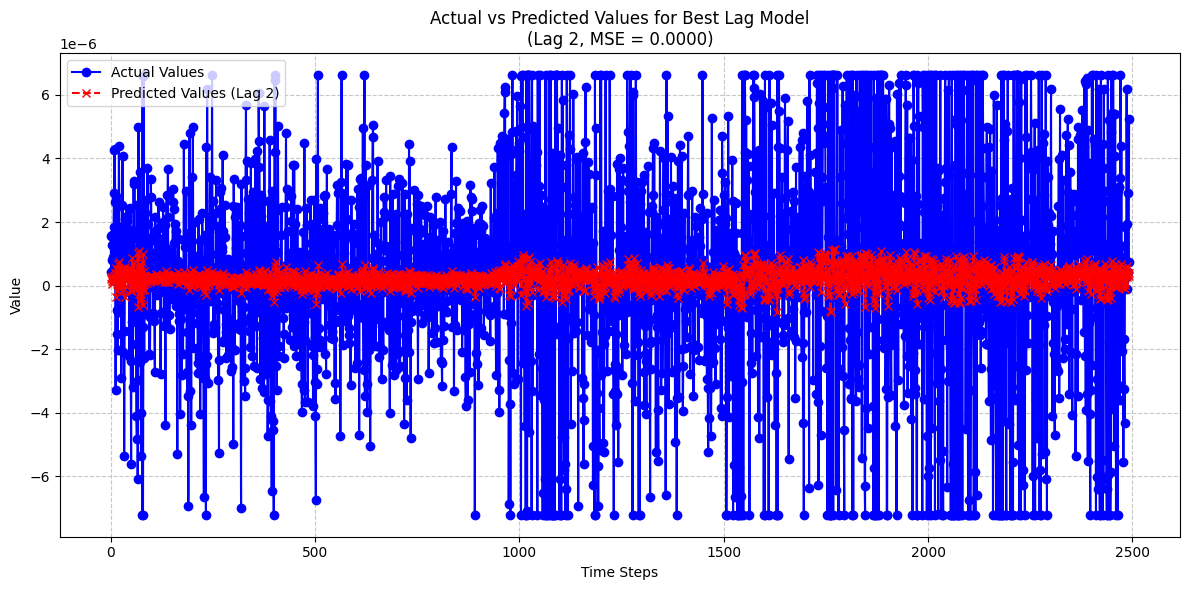

{'best_lag': 2,
 'best_performance': np.float64(1.1579876800489142e-11),
 'reals': [np.float64(1.5675053136406302e-06),
  np.float64(4.26359531351295e-07),
  np.float64(1.5885636363459538e-06),
  np.float64(1.2925649985301029e-06),
  np.float64(8.20740807204134e-07),
  np.float64(9.090306863785404e-07),
  np.float64(5.017492476985691e-07),
  np.float64(1.838258037331991e-06),
  np.float64(2.8990174112067623e-06),
  np.float64(4.271467304907428e-06),
  np.float64(4.2829856189282274e-06),
  np.float64(2.6324393362961252e-06),
  np.float64(-3.2855738826541757e-06),
  np.float64(6.819850869585269e-07),
  np.float64(2.8031938173481424e-06),
  np.float64(-1.5209608636070911e-06),
  np.float64(-7.650434546071037e-07),
  np.float64(-2.0342404420703024e-06),
  np.float64(2.5899922096994207e-06),
  np.float64(-8.313257583882454e-07),
  np.float64(4.3983228309571895e-06),
  np.float64(2.499779232236584e-06),
  np.float64(8.540587986632158e-07),
  np.float64(-8.396960298839733e-07),
  np.float64(1

In [12]:
plot_best_lag_model(data["return_weighted"])

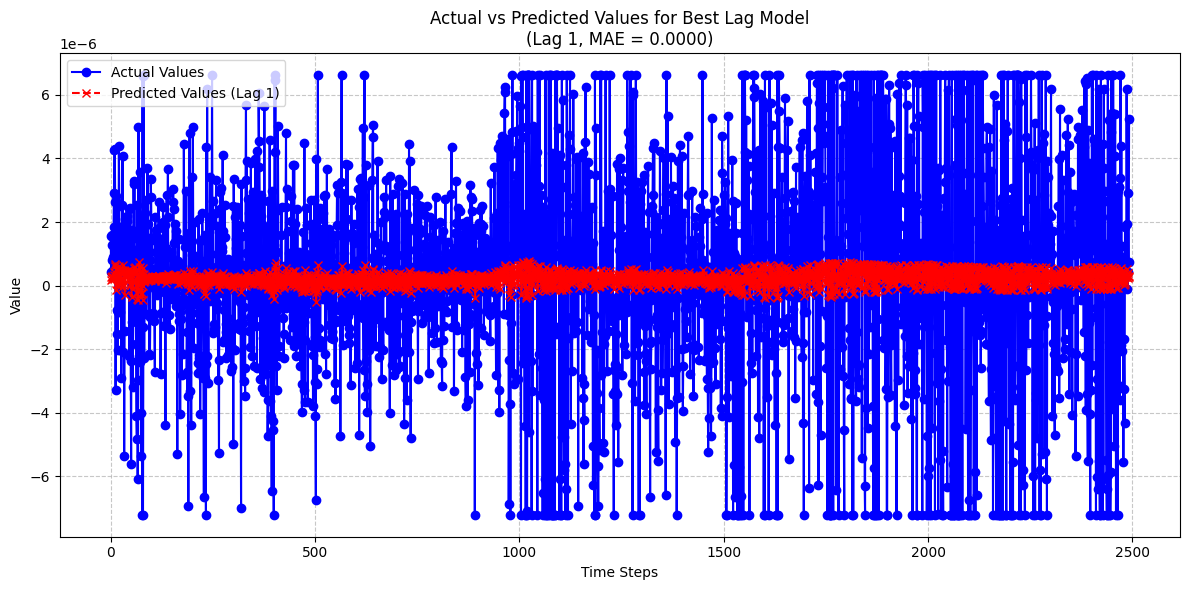

{'best_lag': 1,
 'best_performance': np.float64(2.6221203436394612e-06),
 'reals': [np.float64(1.5675053136406302e-06),
  np.float64(4.26359531351295e-07),
  np.float64(1.5885636363459538e-06),
  np.float64(1.2925649985301029e-06),
  np.float64(8.20740807204134e-07),
  np.float64(9.090306863785404e-07),
  np.float64(5.017492476985691e-07),
  np.float64(1.838258037331991e-06),
  np.float64(2.8990174112067623e-06),
  np.float64(4.271467304907428e-06),
  np.float64(4.2829856189282274e-06),
  np.float64(2.6324393362961252e-06),
  np.float64(-3.2855738826541757e-06),
  np.float64(6.819850869585269e-07),
  np.float64(2.8031938173481424e-06),
  np.float64(-1.5209608636070911e-06),
  np.float64(-7.650434546071037e-07),
  np.float64(-2.0342404420703024e-06),
  np.float64(2.5899922096994207e-06),
  np.float64(-8.313257583882454e-07),
  np.float64(4.3983228309571895e-06),
  np.float64(2.499779232236584e-06),
  np.float64(8.540587986632158e-07),
  np.float64(-8.396960298839733e-07),
  np.float64(1

In [13]:
plot_best_lag_model(data["return_weighted"], metric="mae")

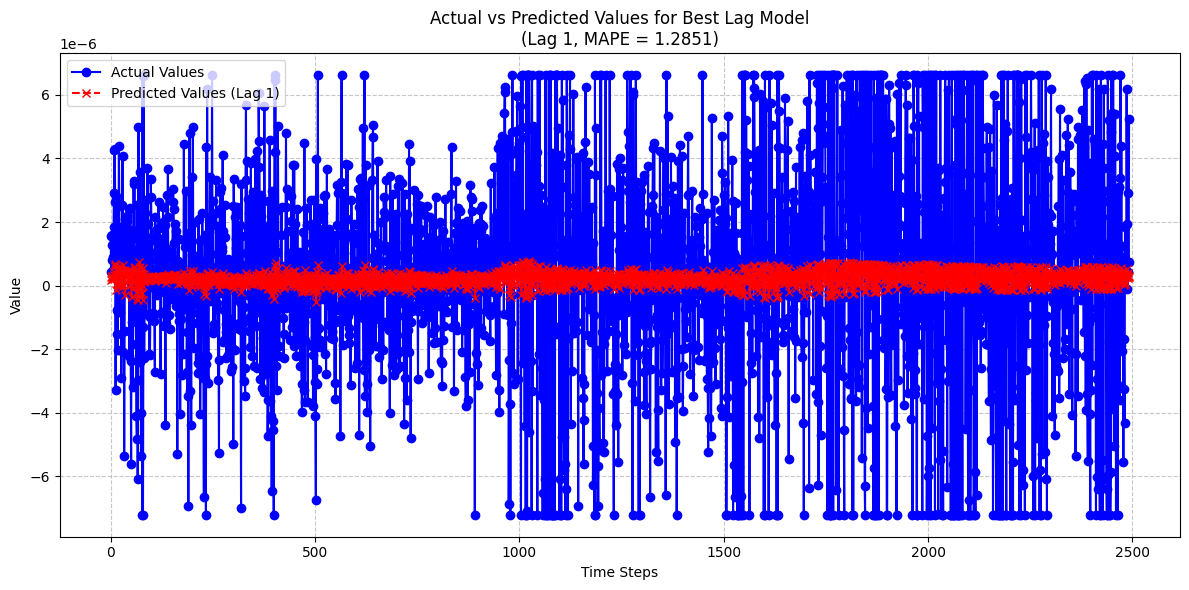

{'best_lag': 1,
 'best_performance': np.float64(1.2850926069874702),
 'reals': [np.float64(1.5675053136406302e-06),
  np.float64(4.26359531351295e-07),
  np.float64(1.5885636363459538e-06),
  np.float64(1.2925649985301029e-06),
  np.float64(8.20740807204134e-07),
  np.float64(9.090306863785404e-07),
  np.float64(5.017492476985691e-07),
  np.float64(1.838258037331991e-06),
  np.float64(2.8990174112067623e-06),
  np.float64(4.271467304907428e-06),
  np.float64(4.2829856189282274e-06),
  np.float64(2.6324393362961252e-06),
  np.float64(-3.2855738826541757e-06),
  np.float64(6.819850869585269e-07),
  np.float64(2.8031938173481424e-06),
  np.float64(-1.5209608636070911e-06),
  np.float64(-7.650434546071037e-07),
  np.float64(-2.0342404420703024e-06),
  np.float64(2.5899922096994207e-06),
  np.float64(-8.313257583882454e-07),
  np.float64(4.3983228309571895e-06),
  np.float64(2.499779232236584e-06),
  np.float64(8.540587986632158e-07),
  np.float64(-8.396960298839733e-07),
  np.float64(1.832

In [14]:
plot_best_lag_model(data["return_weighted"], metric="mape")

<Figure size 1000x500 with 0 Axes>

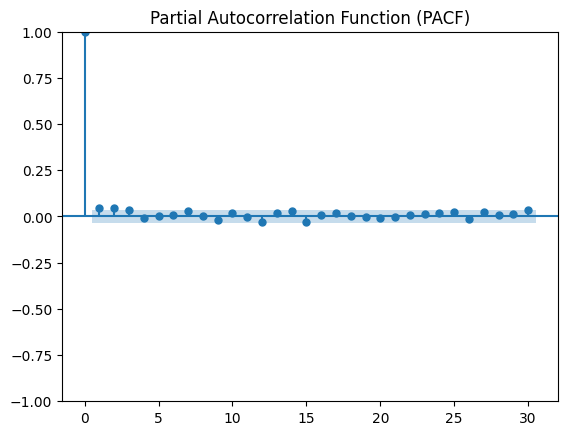

In [10]:
pacf_results = partial_autocorrelation_selection(
    data["return_weighted"]
)

# test stationary

In [8]:
from test_and_visualize import *

In [9]:
for i in market["exchange"].unique():
    if i not in ["BOND", "DELISTED"]:
        temp = market[market["exchange"] == i]["return_weighted"]
        returns = winsorize(temp, limits=[0.05, 0.05])
        print(i, flush=True)
        print("adf_test result:", flush=True)
        adf_test(temp, 0.01)
        print("kpss_test result:", flush=True)
        kpss_test(temp, 0.01)

HNX
adf_test result:


ic| adf_statistic: np.float64(-5.900547991482211)
    p_value: np.float64(2.784726840987283e-07)
    critical_values: {'1%': np.float64(-3.4325731694738972),
                      '10%': np.float64(-2.5672928784456595),
                      '5%': np.float64(-2.862522249592085)}


Judgment: The series is likely stationary (Reject null hypothesis).


kpss_test result:


The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

ic| kpss_statistic: np.float64(2.386163853789992)
    p_value: np.float64(0.01)
    critical_values: {'1%': 0.739, '10%': 0.347, '2.5%': 0.574, '5%': 0.463}


Judgment: The series is likely stationary (Fail to reject null hypothesis).


HSX
adf_test result:


...

Judgment: The series is likely stationary (Fail to reject null hypothesis).


vni
adf_test result:


ic| adf_statistic: np.float64(-27.830463530328988)
    p_value: 0.0
    critical_values: {'1%': np.float64(-3.432737101522179),
                      '10%': np.float64(-2.567331423936805),
                      '5%': np.float64(-2.8625946496914145)}


Judgment: The series is likely stationary (Reject null hypothesis).


kpss_test result:


The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

ic| kpss_statistic: np.float64(0.18088818850635835)
    p_value: np.float64(0.1)
    critical_values: {'1%': 0.739, '10%': 0.347, '2.5%': 0.574, '5%': 0.463}


Judgment: The series is likely stationary (Fail to reject null hypothesis).




# Seasonarity

* with the cycle is 2 year: the trend is more observable

HNX


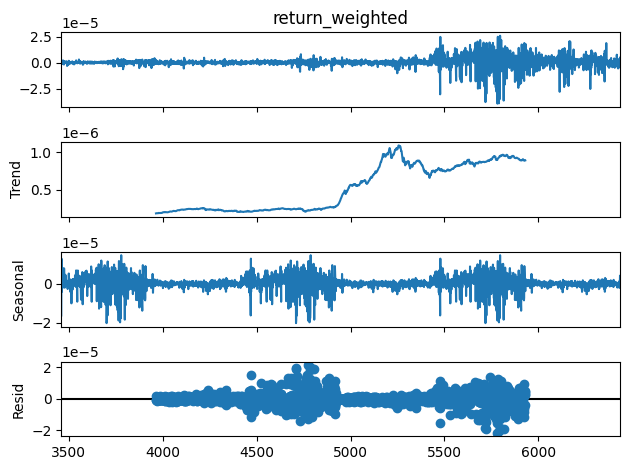

HSX


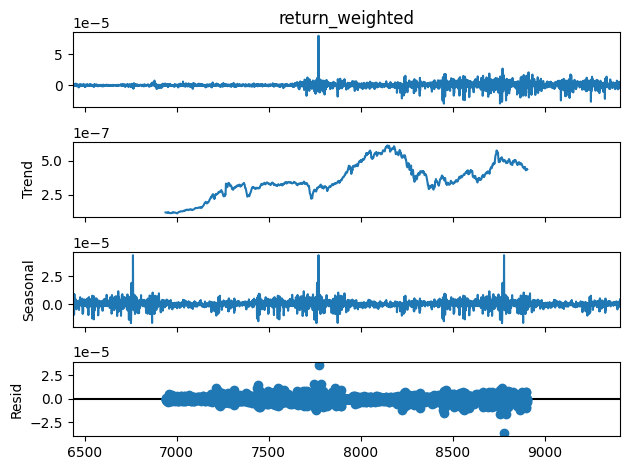

UPCOM


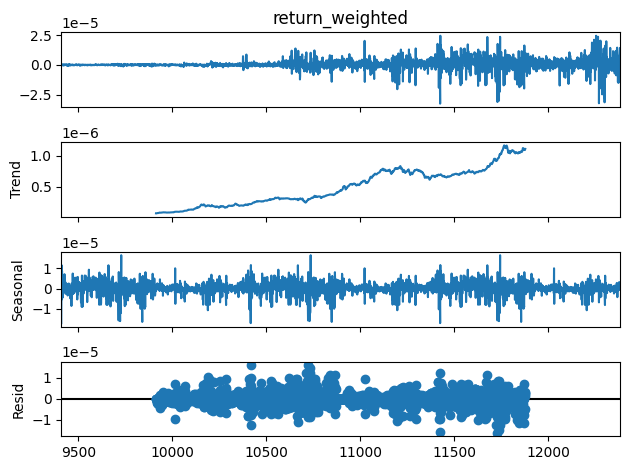

vn30
plot 1 year cycles


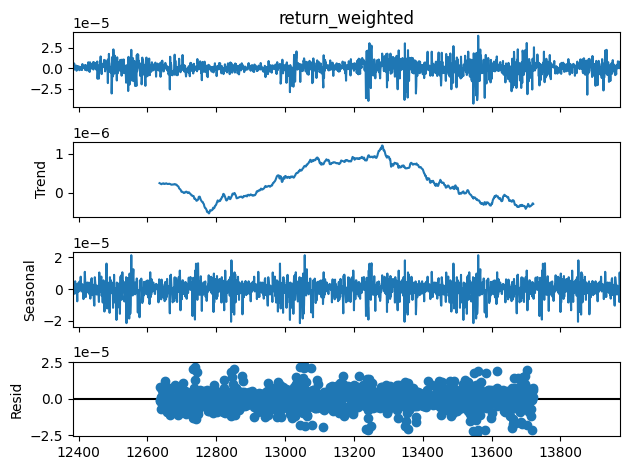

vni


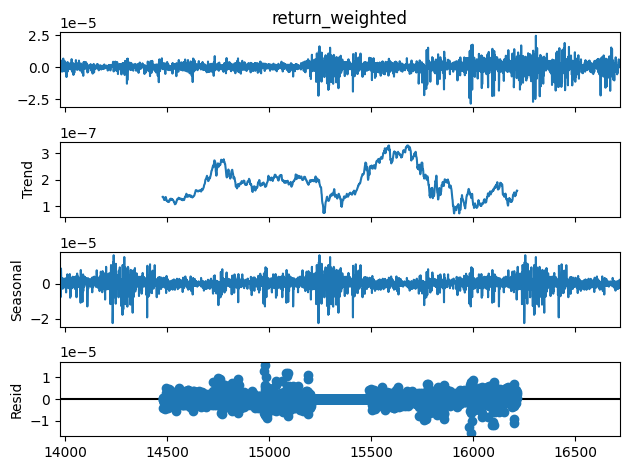

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

period = 2
for i in market["exchange"].unique():
    if i not in ["BOND", "DELISTED"]:
        print(i)
        try:
            temp = market[market["exchange"] == i]["return_weighted"]
            result = seasonal_decompose(
                temp, model="additive", period=period * 252 * 2
            )
            result.plot()
            plt.close()
        except (ValueError, TypeError):
            print("plot 1 year cycles")

            result = seasonal_decompose(
                temp, model="additive", period=period * 252
            )
            result.plot()
            plt.close()

* With 1 year cycle: the trend might not be so clear

ic| i: 'HNX'


'HNX'

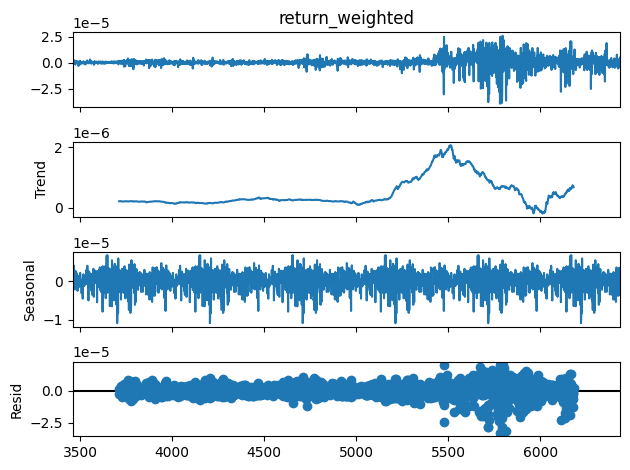

ic| i: 'HSX'


'HSX'

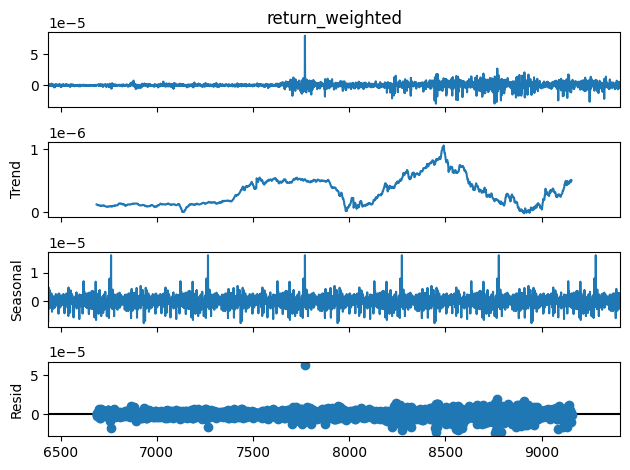

ic| i: 'UPCOM'


'UPCOM'

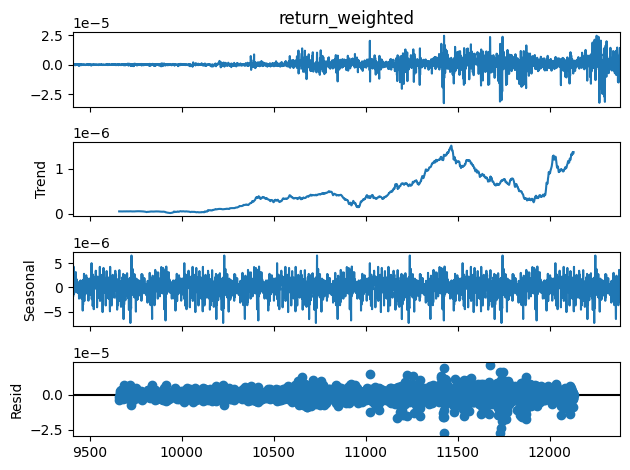

ic| i: 'vn30'


'vn30'

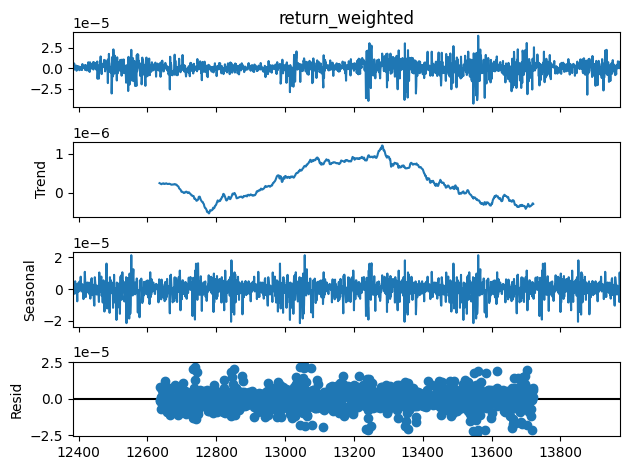

ic| i: 'vni'


'vni'

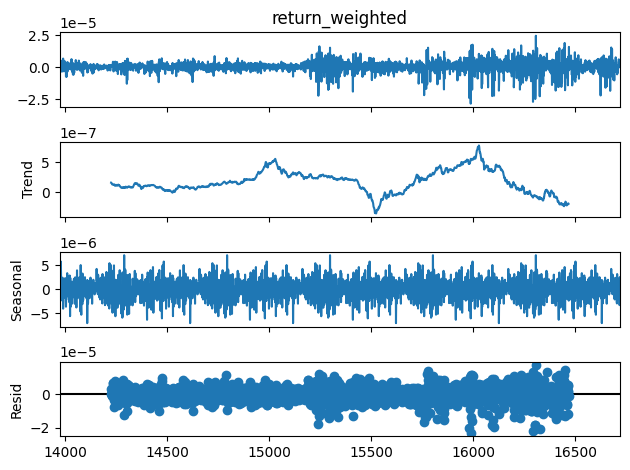

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

period = 1
for i in market["exchange"].unique():
    if i not in ["BOND", "DELISTED"]:
        ic(i)
        try:
            temp = market[market["exchange"] == i]["return_weighted"]
            result = seasonal_decompose(
                temp, model="additive", period=period * 252 * 2
            )
            result.plot()
            plt.close()
        except ValueError:
            print("plot 1 year cycles")
            result = seasonal_decompose(
                temp, model="additive", period=period * 252
            )
            result.plot()
            plt.close()

HSX


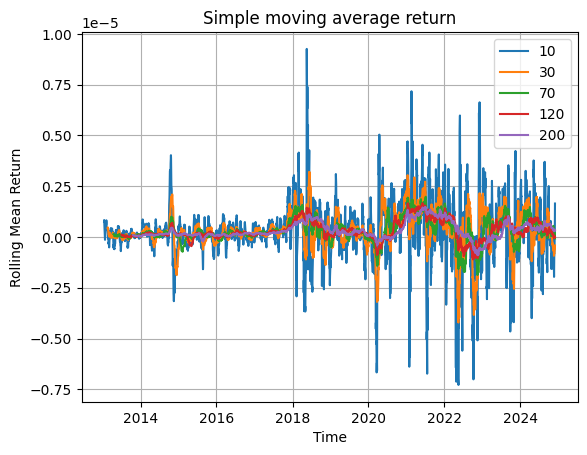

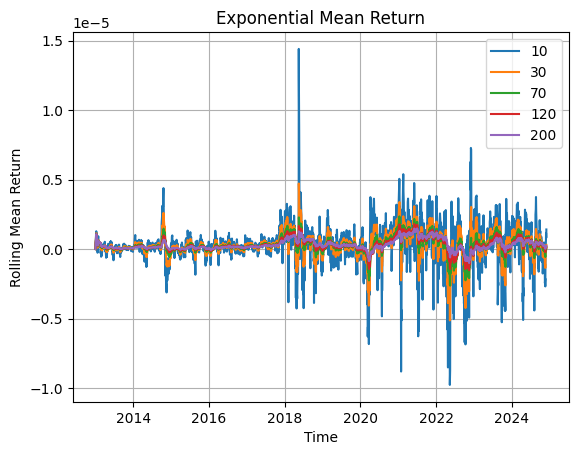

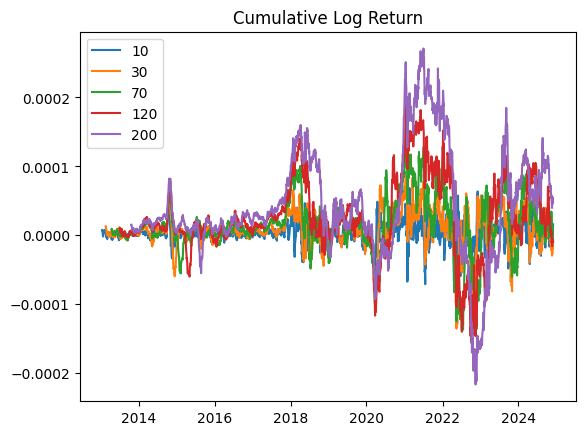

vn30


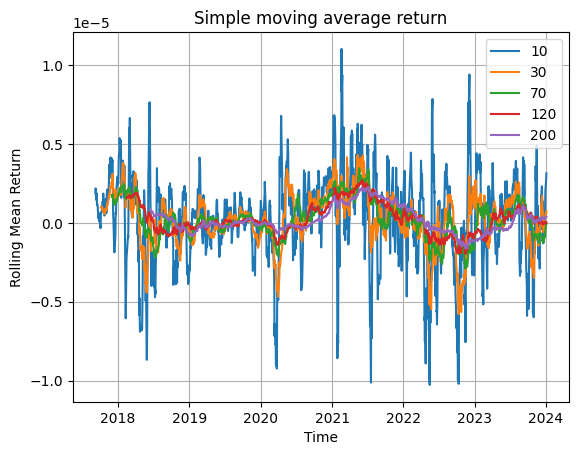

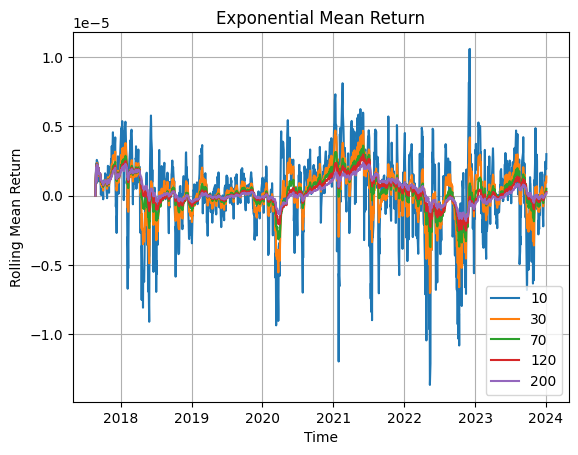

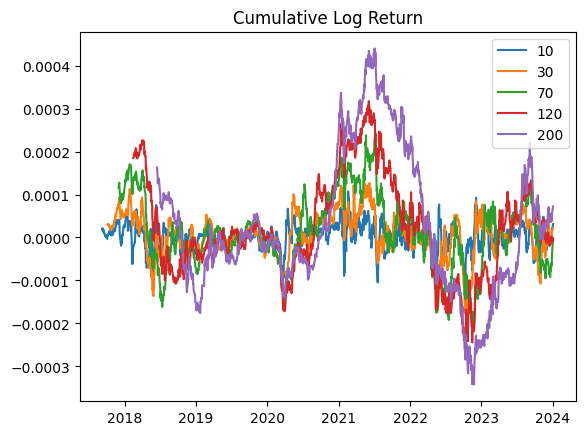

vni


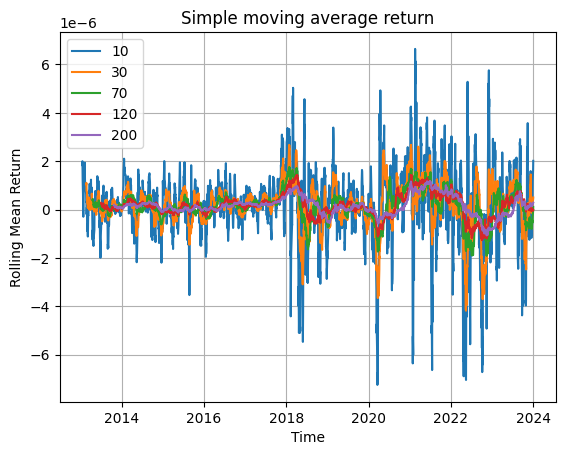

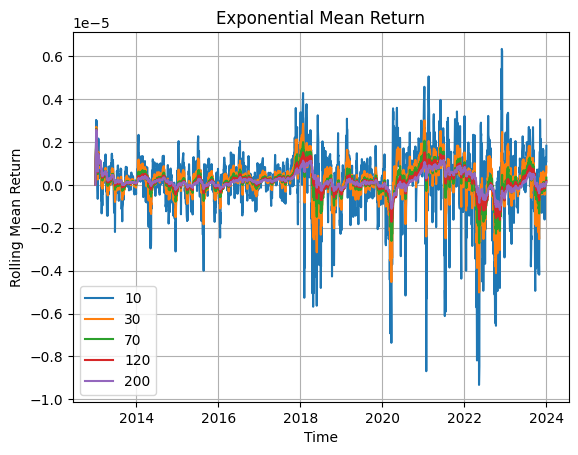

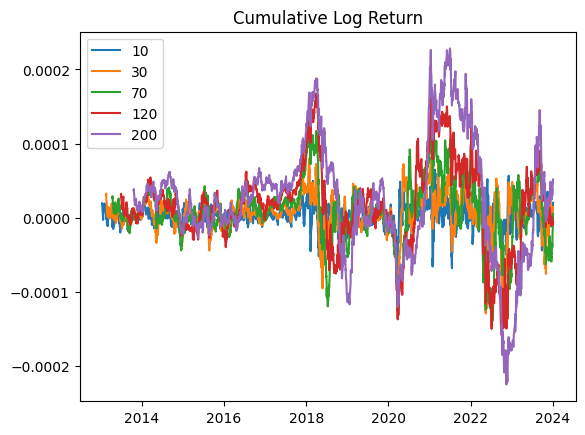

In [12]:
windows = [10, 30, 70, 120, 200]  # number of trading dates
for i in market["exchange"].unique():
    if i in ["HSX", "vni", "vn30"]:
        temp = market[market["exchange"] == i]
        print(i)
        simple_moving_average_visual(temp, "return_weighted", windows)
        exponential_moving_average_visual(
            temp, "return_weighted", windows
        )
        cumulative_visual(temp, "log_return_weighted", windows)

# Visualize with AR and ARIMA regression

'vni'

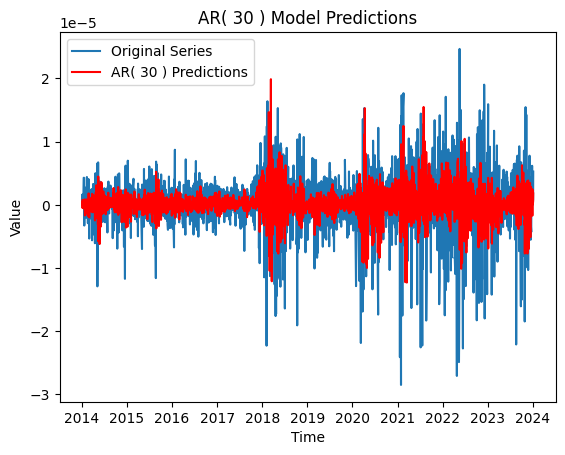

'HSX'

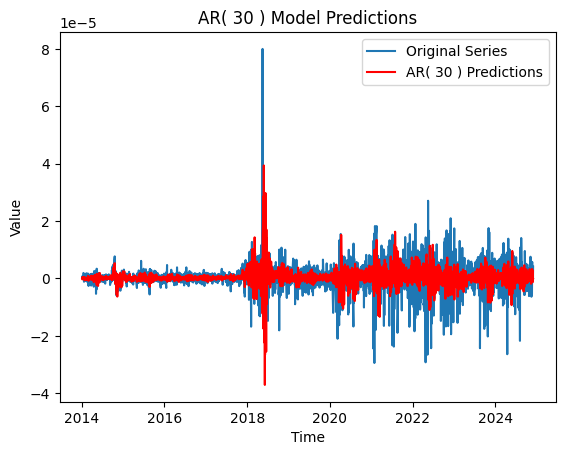

'vn30'

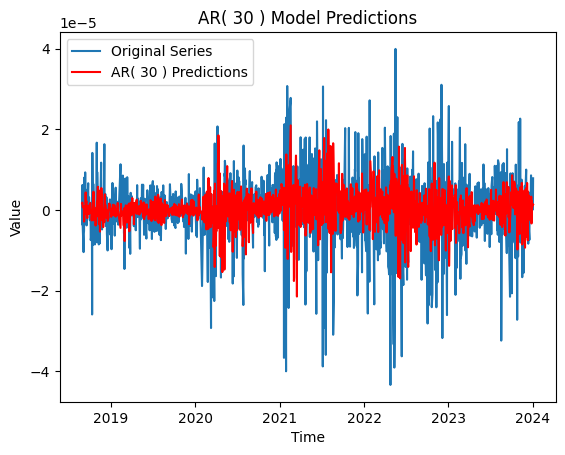

In [13]:
for i in ["vni", "HSX", "vn30"]:
    i
    df = real_time_auto_regression_visualize(
        market[market["exchange"] == i],
        "return_weighted",
        "time",
        252,
        30,
    )

In [14]:
from ARIMA import *

In [16]:
test = market[market["exchange"] == "vni"]
arima = ArimaForecast(test, "time", "return_weighted", 252)

# 15mins

In [17]:
arima._find_best_order()

Maximum Likelihood optimization failed to converge. Check mle_retvals
Maximum Likelihood optimization failed to converge. Check mle_retvals
Maximum Likelihood optimization failed to converge. Check mle_retvals
Maximum Likelihood optimization failed to converge. Check mle_retvals
Maximum Likelihood optimization failed to converge. Check mle_retvals
Maximum Likelihood optimization failed to converge. Check mle_retvals
Maximum Likelihood optimization failed to converge. Check mle_retvals
Maximum Likelihood optimization failed to converge. Check mle_retvals
Maximum Likelihood optimization failed to converge. Check mle_retvals
Maximum Likelihood optimization failed to converge. Check mle_retvals
Maximum Likelihood optimization failed to converge. Check mle_retvals
Maximum Likelihood optimization failed to converge. Check mle_retvals
Maximum Likelihood optimization failed to converge. Check mle_retvals
Maximum Likelihood optimization failed to converge. Check mle_retvals
Maximum Likelihood o

LinAlgError: Schur decomposition solver error.

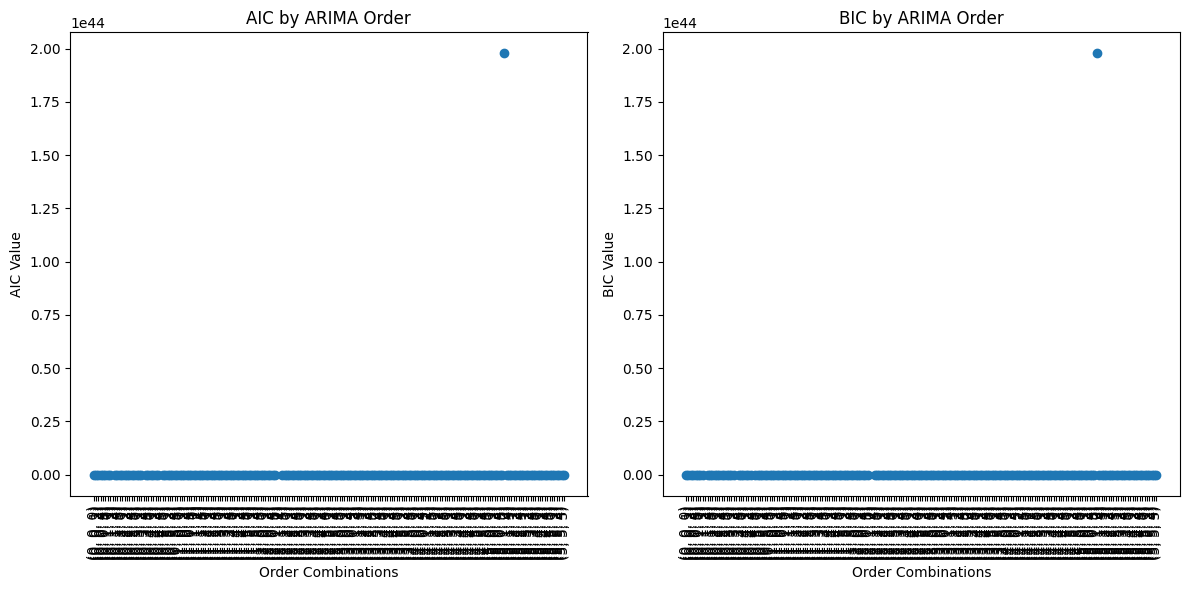

Best Order by AIC: (1, 1, 0)
Best Order by BIC: (1, 1, 0)


{'best_aic_order': {'order': (1, 1, 0),
  'aic': np.float64(-58801.295353216876),
  'bic': np.float64(-58789.46100923918)},
 'best_bic_order': {'order': (1, 1, 0),
  'aic': np.float64(-58801.295353216876),
  'bic': np.float64(-58789.46100923918)},
 'all_results': [{'order': (0, 0, 0),
   'aic': np.float64(-57571.534075373296),
   'bic': np.float64(-57559.69900266541)},
  {'order': (0, 0, 1),
   'aic': np.float64(-57592.98875093846),
   'bic': np.float64(-57575.23614187662)},
  {'order': (0, 0, 2),
   'aic': np.float64(-57637.73131892538),
   'bic': np.float64(-57614.0611735096)},
  {'order': (0, 0, 3),
   'aic': np.float64(-57658.097313886574),
   'bic': np.float64(-57628.50963211685)},
  {'order': (0, 0, 4),
   'aic': np.float64(-57751.21575622171),
   'bic': np.float64(-57715.71053809805)},
  {'order': (0, 0, 5),
   'aic': np.float64(-57957.00746012668),
   'bic': np.float64(-57915.584705649075)},
  {'order': (0, 1, 0),
   'aic': np.float64(-57274.22943309559),
   'bic': np.float64(-

In [ ]:
plot_arima_order_comparison()

In [ ]:
arima_prediction = arima.visualize_ARIMA(para=True,order=[1,1,0])